# ReBRAC C1 — Reward Ablation (efficiency_v2 vs arrival_v2_simple)

> 文档锚点：[docs/rebrac_mainline_review.md](../docs/rebrac_mainline_review.md) · [docs/online_sac_reward_redesign.md](../docs/online_sac_reward_redesign.md)

## 问题背景

S2 P1 **C1**（upstream u10 / crosscomp / s0 / h4 / efficiency_v2）失败：

| metric | value |
|---|---|
| dataset success | **1.000** |
| dataset mean_R | **−108** |
| ReBRAC anchor (β1=4.0, β2=2.0) test success | **0.225 ± 0.005** |
| ReBRAC test mean_R | **−371 ± 0.41** |

S3.b 三组 β refit（anchor 4/2 / refit_a 2/2 / refit_b 4/1）全部落在 0.21–0.24，**不是 β 调参问题**。collapse 的 std 只有 0.005，是典型的 deterministic-collapse 信号。

## 假设

**efficiency_v2 reward 在 upstream 上病态**（已对 online SAC 证实，见 online_sac_reward_redesign.md §3.1）。Offline ReBRAC 的传染机制：

```
dataset_R(success) ≈ −108 (步罚 1.0 × ~480 步 + progress + 100)
    ↓
critic q_target ≈ −108 处处都很负
    ↓
actor 从 BC 起步，BC 改进信号 < BC 惩罚 → 退化到 deterministic policy
    ↓
test 时所有 episode 都 timeout，mean_R = −371
```

C1 的 dataset success=1.000 → 没有 OOB 样本进入训练，所以这里只看「成功-超时」ordering，OOB 的 ordering 暂不重要。

## 验证方案：arrival_v2_simple

用 `auv_nav/reward.py` 新加的 `arrival_v2_simple` preset（doc §5.1 arrival_v2 的 minimal subset，只用现有 RewardModelConfig 字段）重做 collect + train，对 anchor (β1=4.0, β2=2.0) × 2 seeds 跑一次：

| field | efficiency_v2 | arrival_v2_simple | rationale |
|---|---:|---:|---|
| step_penalty | −1.0 | **−0.2** | 5× ↓ time pressure |
| success_reward | 100.0 | **200.0** | 2× ↑ arrival reward |
| failure_penalty | −20.0 | **−200.0** | 10× ↑ OOB cost |
| timeout_penalty | None (=−20.0) | **−50.0** | 单独分支，比 OOB 轻 |
| safety_cost_gain | 0.25 | 0.5 | < flip threshold 3.69 |

## Verdict 逻辑（事先 commit）

| arrival_v2_simple test success | 解读 |
|---:|---|
| **≥ 0.6** | reward landscape 是 C1 失败的主因（α 主导） |
| **0.4–0.6** | reward 与 sensor info 双因素叠加 |
| **≤ 0.4** | sensor info（s0 看不到流场）是主因，reward 改写救不了 |

## 限制（已知，不在本 notebook 验证）

1. `arrival_v2_simple` **不是** doc §5.1 arrival_v2 的完整版 — 缺 normalized progress / normalized time / early-failure-penalty / final-distance-penalty。完整版需要 ~4–6h 工作量，超出本 sprint EV。
2. **不能复用到 online SAC**：没有 early-failure-penalty 时 `fast_OOB(−210) > slow_OOB(−250)` ordering 反序仍然存在，online SAC 仍会学 fast_OOB 的失败模式。本 preset 只对 offline 安全，因为 C1 dataset 没有 OOB 样本。
3. **α' confound**：reward 重写后 critic_bc_coef=2.0 vs Q-magnitude 的相对量级会改变；若 success ≥ 0.6，仍存在「是不是只是 BC penalty 相对变弱」的 confound。但 verdict 仍然成立：无论是 reward 绝对值 (α) 还是 BC penalty 相对量级 (α')，都指向 efficiency_v2 不适合 ReBRAC。

## 1. 环境 sanity check

In [1]:
!lscpu | head -10
print()
!nvidia-smi

Architecture:                            x86_64
CPU op-mode(s):                          32-bit, 64-bit
Address sizes:                           46 bits physical, 48 bits virtual
Byte Order:                              Little Endian
CPU(s):                                  12
On-line CPU(s) list:                     0-11
Vendor ID:                               GenuineIntel
Model name:                              Intel(R) Xeon(R) CPU @ 2.20GHz
CPU family:                              6
Model:                                   85

Wed May  6 08:56:12 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-U

In [2]:
import torch
print(f'PyTorch: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')

PyTorch: 2.10.0+cu128
CUDA available: True


In [3]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
%cd /content/drive/MyDrive/Colab Notebooks/new_offRL/rl_v2_5

Mounted at /content/drive
/content/drive/MyDrive/Colab Notebooks/new_offRL/rl_v2_5


## 2. 通用配置

对齐 `scripts/run_offline_rebrac_broad.sh` 的 ReBRAC anchor 训练配置：
`shuffle_no_replacement` × 64 epochs / hidden 256×3 / γ=0.99 / val=40 / test=100。唯一改动是 `--objective` 从 efficiency_v2 → arrival_v2_simple。

In [4]:
import os
from pathlib import Path

# ---- 锁定（与 broad C1 唯一差异是 OBJECTIVE）----
OBJECTIVE = 'arrival_v2_simple'
PROBE_LAYOUT = 's0'
TASK_GEOMETRY = 'upstream'
TARGET_SPEED = 1.5
HISTORY_LENGTH = 4
FLOW_PATH = 'wake_data/wake_v8_U1p00_Re150_D12p00_dx0p60_Ti5pct_1200f_roi.npy'
BENCHMARK_KEY = 'single_u10_upstream_tgt15'
COLLECTOR_POLICY = 'crosscomp'
DATASET_EPISODES = 1000
DATASET_SEED = 0
COLLECT_WORKERS = 8

# ---- 训练 anchor（与 C1 efficiency_v2 完全一致以隔离 reward 变量）----
ACTOR_PENALTY_COEF = 4.0
CRITIC_PENALTY_COEF = 2.0
TRAIN_SEEDS = [42, 44]
TRAIN_EPOCHS = 64
BATCH_SIZE = 256
HIDDEN_DIM = 256
NUM_HIDDEN_LAYERS = 3
GAMMA = 0.99
TAU = 0.005
ACTOR_LR = 3e-4
CRITIC_LR = 3e-4
POLICY_NOISE = 0.2
NOISE_CLIP = 0.5
POLICY_FREQ = 2
GRAD_CLIP_NORM = 10.0
NORMALIZER_EPS = 1e-3
VAL_EPISODES = 40
TEST_EPISODES = 100

# ---- 输出树（与 broad_validation 隔离）----
DATASET_NAME = (
    f'{COLLECTOR_POLICY}_{PROBE_LAYOUT}_h{HISTORY_LENGTH}_{OBJECTIVE}'
    f'_re150_u10upstream_fixdone_ep{DATASET_EPISODES}'
)
DATASET_DIR = Path('offline_data') / DATASET_NAME
CHECKPOINT_ROOT = Path('checkpoints/offline/rebrac/c1_reward_ablation')
RESULTS_ROOT = Path('results/offline/rebrac/c1_reward_ablation')
VAL_MANIFEST_PATH = Path(f'benchmarks/c1_reward_ablation/val_{VAL_EPISODES}/{BENCHMARK_KEY}.json')
TEST_MANIFEST_PATH = Path(f'benchmarks/c1_reward_ablation/test_{TEST_EPISODES}/{BENCHMARK_KEY}.json')

print(f'DATASET_NAME    = {DATASET_NAME}')
print(f'DATASET_DIR     = {DATASET_DIR}')
print(f'VAL_MANIFEST    = {VAL_MANIFEST_PATH}')
print(f'TEST_MANIFEST   = {TEST_MANIFEST_PATH}')
print(f'CHECKPOINT_ROOT = {CHECKPOINT_ROOT}')
print(f'RESULTS_ROOT    = {RESULTS_ROOT}')

DATASET_NAME    = crosscomp_s0_h4_arrival_v2_simple_re150_u10upstream_fixdone_ep1000
DATASET_DIR     = offline_data/crosscomp_s0_h4_arrival_v2_simple_re150_u10upstream_fixdone_ep1000
VAL_MANIFEST    = benchmarks/c1_reward_ablation/val_40/single_u10_upstream_tgt15.json
TEST_MANIFEST   = benchmarks/c1_reward_ablation/test_100/single_u10_upstream_tgt15.json
CHECKPOINT_ROOT = checkpoints/offline/rebrac/c1_reward_ablation
RESULTS_ROOT    = results/offline/rebrac/c1_reward_ablation


## 3. 任务 1 — Collect crosscomp dataset (arrival_v2_simple)

1000 episodes × upstream / u10 / s0 / h4，objective 用 `arrival_v2_simple`。complexity 与 C1 efficiency_v2 dataset 完全一致，唯一变量是 reward labels。

In [ ]:
TRANSITIONS_NPZ = str(DATASET_DIR / 'transitions.npz')
DATASET_DIR_STR = str(DATASET_DIR)

if (DATASET_DIR / 'transitions.npz').exists():
    print(f'[skip] dataset exists: {DATASET_DIR}')
else:
    DATASET_DIR.parent.mkdir(parents=True, exist_ok=True)
    !python -m scripts.collect_offline_data \
        --policy {COLLECTOR_POLICY} \
        --flow {FLOW_PATH} \
        --probe-layout {PROBE_LAYOUT} \
        --task-geometry {TASK_GEOMETRY} \
        --target-speed {TARGET_SPEED} \
        --history-length {HISTORY_LENGTH} \
        --objective {OBJECTIVE} \
        --episodes {DATASET_EPISODES} \
        --seed {DATASET_SEED} \
        --num-workers {COLLECT_WORKERS} \
        --output-dir {DATASET_DIR_STR}

[collect] ep=125/1000 transitions=32401 success_rate=100.00% elapsed=500.5s
[collect] ep=250/1000 transitions=66274 success_rate=100.00% elapsed=500.5s
[collect] ep=375/1000 transitions=100381 success_rate=100.00% elapsed=500.5s
[collect] ep=500/1000 transitions=134203 success_rate=100.00% elapsed=500.5s
[collect] ep=625/1000 transitions=167327 success_rate=100.00% elapsed=500.5s
[collect] ep=750/1000 transitions=201330 success_rate=100.00% elapsed=500.5s
[collect] ep=875/1000 transitions=234524 success_rate=100.00% elapsed=500.5s
[collect] ep=1000/1000 transitions=268329 success_rate=100.00% elapsed=500.5s

[done] Saved 268329 transitions to offline_data/crosscomp_s0_h4_arrival_v2_simple_re150_u10upstream_fixdone_ep1000/transitions.npz
  policy=crosscomp  obs_dim=40  action_dim=2
  episodes=1000  success_rate=100.00%
  mean_return=205.34 +/- 9.62


## 4. Sanity card + reward distribution

对齐 broad_validation §2.4 的 sanity card 检查（obs_dim / probe_layout / success / mean_R），再加一个 reward-landscape 直方图（mean_R / episode_length / terminal_R），验证 arrival_v2_simple 把 successful 轨迹的 mean_R 从 −108 推到正区间。

In [ ]:
!python -m scripts.write_sanity_card \
    --dataset-dir {DATASET_DIR_STR} \
    --expected-probe-layout {PROBE_LAYOUT}

[write] sanity card: offline_data/crosscomp_s0_h4_arrival_v2_simple_re150_u10upstream_fixdone_ep1000/sanity_card.json
  collector_success_rate: 1.0
  collector_mean_return: 205.34033653465735
  episode_length_mean: 268.329
  episode_length_std: 66.72772106853343
  obs_dim: 40
  n_transitions: 268329
  privileged_obs_present: True
  flow_file: wake_v8_U1p00_Re150_D12p00_dx0p60_Ti5pct_1200f_roi.npy
  n_episodes: 1000
  expected_probe_layout: s0
  history_length: 4
  expected_obs_dim: 40
  obs_dim_matches_probe_layout: True


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

data = np.load(DATASET_DIR / 'transitions.npz')
rewards = data['rewards']
dones = data['dones']
print(f'transitions = {len(rewards):,}')

# Recover episodes by splitting on done==1
done_idx = np.flatnonzero(dones)
starts = np.concatenate([[0], done_idx[:-1] + 1])
ends = done_idx + 1
ep_returns = np.array([rewards[s:e].sum() for s, e in zip(starts, ends)])
ep_lengths = ends - starts
ep_terminal_r = np.array([rewards[e - 1] for e in ends])
ep_step_r = np.array([rewards[s:e - 1].mean() if e - 1 > s else 0.0 for s, e in zip(starts, ends)])

print(f'episodes        = {len(ep_returns):,}')
print(f'mean_R          = {ep_returns.mean():+.2f}  (std {ep_returns.std():.2f})')
print(f'mean episode L  = {ep_lengths.mean():.1f}    (std {ep_lengths.std():.1f})')
print(f'mean terminal_R = {ep_terminal_r.mean():+.2f} (std {ep_terminal_r.std():.2f})')
print(f'mean step_R     = {ep_step_r.mean():+.4f}   (std {ep_step_r.std():.4f})')

# Compare with C1 efficiency_v2 anchor
EFF_V2_C1_MEAN_R = -108.0
delta_mean_R = ep_returns.mean() - EFF_V2_C1_MEAN_R
print()
print(f'[vs efficiency_v2 C1]  ΔmeanR = {delta_mean_R:+.2f}  '
      f'({"better" if delta_mean_R > 0 else "worse"})')

transitions = 268,329
episodes        = 1,000
mean_R          = +205.34  (std 9.62)
mean episode L  = 268.3    (std 66.7)
mean terminal_R = +199.93 (std 0.08)
mean step_R     = +0.0225   (std 0.0358)

[vs efficiency_v2 C1]  ΔmeanR = +313.34  (better)


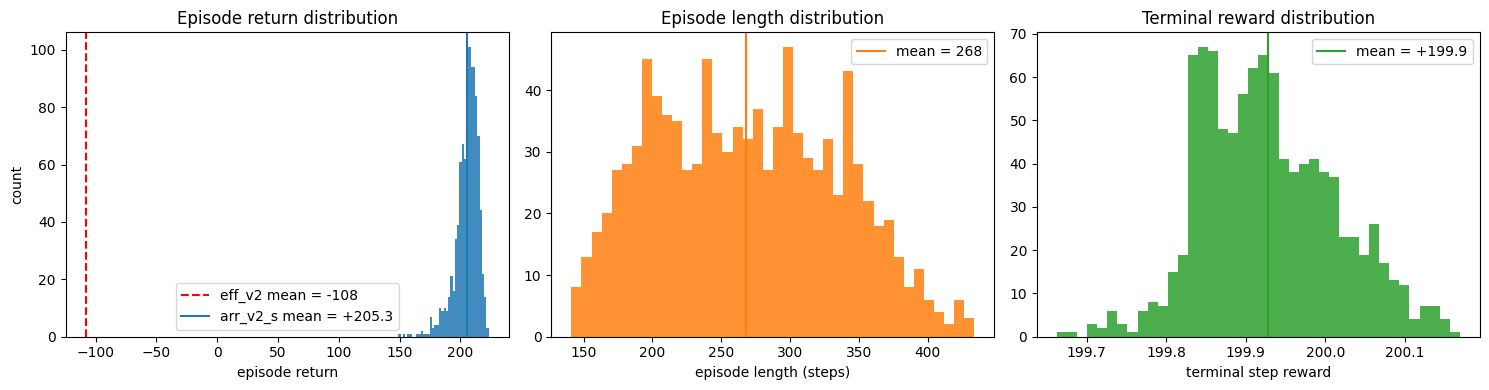

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(ep_returns, bins=40, color='C0', alpha=0.85)
axes[0].axvline(EFF_V2_C1_MEAN_R, color='red', linestyle='--', label=f'eff_v2 mean = {EFF_V2_C1_MEAN_R:+.0f}')
axes[0].axvline(ep_returns.mean(), color='C0', linestyle='-', label=f'arr_v2_s mean = {ep_returns.mean():+.1f}')
axes[0].set_xlabel('episode return')
axes[0].set_ylabel('count')
axes[0].set_title('Episode return distribution')
axes[0].legend()
axes[1].hist(ep_lengths, bins=40, color='C1', alpha=0.85)
axes[1].axvline(ep_lengths.mean(), color='C1', linestyle='-', label=f'mean = {ep_lengths.mean():.0f}')
axes[1].set_xlabel('episode length (steps)')
axes[1].set_title('Episode length distribution')
axes[1].legend()
axes[2].hist(ep_terminal_r, bins=40, color='C2', alpha=0.85)
axes[2].axvline(ep_terminal_r.mean(), color='C2', linestyle='-', label=f'mean = {ep_terminal_r.mean():+.1f}')
axes[2].set_xlabel('terminal step reward')
axes[2].set_title('Terminal reward distribution')
axes[2].legend()
plt.tight_layout()
plt.show()

## 5. 任务 2 — Train ReBRAC anchor (β1=4.0, β2=2.0) × 2 seeds

强制 collect/train objective 一致（`train_offline.py:190-194`），所以本节训练命令也加 `--objective arrival_v2_simple`。其他超参与 `run_offline_rebrac_broad.sh` C1 anchor 完全一致。

为节省时间，先生成 val/test manifest（如果不存在）。

In [ ]:
VAL_MANIFEST_PATH.parent.mkdir(parents=True, exist_ok=True)
TEST_MANIFEST_PATH.parent.mkdir(parents=True, exist_ok=True)
VAL_MANIFEST_DIR_STR  = str(VAL_MANIFEST_PATH.parent)
TEST_MANIFEST_DIR_STR = str(TEST_MANIFEST_PATH.parent)
VAL_MANIFEST_STR  = str(VAL_MANIFEST_PATH)
TEST_MANIFEST_STR = str(TEST_MANIFEST_PATH)

if not VAL_MANIFEST_PATH.exists():
    !python -m scripts.generate_standard_benchmarks \
        --benchmarks {BENCHMARK_KEY} \
        --episodes {VAL_EPISODES} \
        --output-dir {VAL_MANIFEST_DIR_STR}
else:
    print(f'[skip] val manifest exists: {VAL_MANIFEST_PATH}')

if not TEST_MANIFEST_PATH.exists():
    !python -m scripts.generate_standard_benchmarks \
        --benchmarks {BENCHMARK_KEY} \
        --episodes {TEST_EPISODES} \
        --output-dir {TEST_MANIFEST_DIR_STR}
else:
    print(f'[skip] test manifest exists: {TEST_MANIFEST_PATH}')

[done] single_u10_upstream_tgt15 -> benchmarks/c1_reward_ablation/val_40/single_u10_upstream_tgt15.json
[done] single_u10_upstream_tgt15 -> benchmarks/c1_reward_ablation/test_100/single_u10_upstream_tgt15.json


In [ ]:
PAIR_TAG = f'actorb_{ACTOR_PENALTY_COEF:.1f}__criticb_{CRITIC_PENALTY_COEF:.1f}'.replace('.', 'p')

def seed_dir(seed: int) -> Path:
    return CHECKPOINT_ROOT / DATASET_NAME / PAIR_TAG / f'seed_{seed}'

for seed in TRAIN_SEEDS:
    save_dir = seed_dir(seed)
    save_dir_str = str(save_dir)
    if (save_dir / 'agent_final.pt').exists():
        print(f'[skip] seed {seed} done: {save_dir}')
        continue
    print(f'\n========== train seed {seed} → {save_dir} ==========')
    !python -m scripts.train_offline \
        --algo rebrac \
        --offline-data {TRANSITIONS_NPZ} \
        --flow {FLOW_PATH} \
        --manifest {VAL_MANIFEST_STR} \
        --probe-layout {PROBE_LAYOUT} \
        --history-length {HISTORY_LENGTH} \
        --task-geometry {TASK_GEOMETRY} \
        --target-speed {TARGET_SPEED} \
        --objective {OBJECTIVE} \
        --sampling-mode shuffle_no_replacement \
        --num-epochs {TRAIN_EPOCHS} \
        --batch-size {BATCH_SIZE} \
        --hidden-dim {HIDDEN_DIM} \
        --num-hidden-layers {NUM_HIDDEN_LAYERS} \
        --gamma {GAMMA} \
        --tau {TAU} \
        --actor-lr {ACTOR_LR} \
        --critic-lr {CRITIC_LR} \
        --actor-penalty-coef {ACTOR_PENALTY_COEF} \
        --critic-penalty-coef {CRITIC_PENALTY_COEF} \
        --policy-noise {POLICY_NOISE} \
        --noise-clip {NOISE_CLIP} \
        --policy-freq {POLICY_FREQ} \
        --grad-clip-norm {GRAD_CLIP_NORM} \
        --normalizer-eps {NORMALIZER_EPS} \
        --eval-every 0 \
        --skip-final-eval \
        --seed {seed} \
        --device cuda \
        --save-dir {save_dir_str}


========== train seed 42 → checkpoints/offline/rebrac/c1_reward_ablation/crosscomp_s0_h4_arrival_v2_simple_re150_u10upstream_fixdone_ep1000/actorb_4p0__criticb_2p0/seed_42 ==========
[offline] algo=rebrac transitions=268329 obs_dim=40 action_dim=2 protocol=deployable tensor_replay=on eval_workers=1 sampling=shuffle_no_replacement total_steps=67136
[train] step=1 epoch=1 epoch_step=1 q=-0.927 critic=165.002 actor=5.655 bc=1.164 lambda=1.079 critic_pen=1.244
[train] step=1000 epoch=1 epoch_step=1000 q=-2.731 critic=138.105 actor=0.916 bc=0.037 lambda=0.281 critic_pen=0.086
[train] step=2000 epoch=2 epoch_step=951 q=-2.266 critic=2.313 actor=0.576 bc=0.027 lambda=0.207 critic_pen=0.078
[train] step=3000 epoch=3 epoch_step=902 q=-1.005 critic=152.565 actor=0.245 bc=0.022 lambda=0.155 critic_pen=0.093
[train] step=4000 epoch=4 epoch_step=853 q=-1.350 critic=3.116 actor=0.316 bc=0.029 lambda=0.147 critic_pen=0.090
[train] step=5000 epoch=5 epoch_step=804 q=0.590 critic=8.993 actor=0.064 bc=

### 5.1 Test eval — 100-episode 在 test manifest 上

用 `scripts.evaluate_offline` 加载每个 seed 的 final checkpoint，在 100-episode test manifest 上跑评估。结果写到 `RESULTS_ROOT/<DATASET>/<PAIR_TAG>/test/seed_<S>.json`。并行 6 worker × CPU 与 broad bash 一致。

In [ ]:
import json

TEST_DIR = RESULTS_ROOT / DATASET_NAME / PAIR_TAG / 'test'
TEST_DIR.mkdir(parents=True, exist_ok=True)
EVAL_NUM_WORKERS = 6

for seed in TRAIN_SEEDS:
    out_path = TEST_DIR / f'seed_{seed}.json'
    out_path_str = str(out_path)
    if out_path.exists():
        print(f'[skip] eval done: {out_path}')
        continue
    save_dir = seed_dir(seed)
    save_dir_str = str(save_dir)
    if not (save_dir / 'agent_final.pt').exists():
        print(f'[warn] missing checkpoint: {save_dir}')
        continue
    print(f'\n========== eval seed {seed} → {out_path} ==========')
    !python -m scripts.evaluate_offline \
        --checkpoint {save_dir_str} \
        --manifest {TEST_MANIFEST_STR} \
        --episodes {TEST_EPISODES} \
        --num-workers {EVAL_NUM_WORKERS} \
        --worker-device cpu \
        --device cuda \
        --output-json {out_path_str}


========== eval seed 42 → results/offline/rebrac/c1_reward_ablation/crosscomp_s0_h4_arrival_v2_simple_re150_u10upstream_fixdone_ep1000/actorb_4p0__criticb_2p0/test/seed_42.json ==========
reward_objective      : arrival_v2_simple
energy_cost_gain      : 0.000000
safety_cost_gain      : 0.500000
episodes              : 100
success_rate          : 20.0%
avg_return            : -102.25 +/- 157.14
avg_safety_cost       : 25.748 +/- 39.507
avg_time_s            : 203.73 +/- 49.45
avg_time_s_success    : 127.76
avg_energy            : 125844.25 +/- 30276.17
avg_path_length_m     : 99.29 +/- 29.43
avg_progress_ratio    : 0.471 +/- 0.398
avg_path_efficiency   : 0.383 +/- 0.328
termination           : {'timeout': 54, 'out_of_bounds': 26, 'goal': 20}
benchmark_manifest    : benchmarks/c1_reward_ablation/test_100/single_u10_upstream_tgt15.json

========== eval seed 44 → results/offline/rebrac/c1_reward_ablation/crosscomp_s0_h4_arrival_v2_simple_re150_u10upstream_fixdone_ep1000/actorb_4p0__critic

## 6. 对比：efficiency_v2 vs arrival_v2_simple

锚点：S2 P1 C1 efficiency_v2 anchor (4.0, 2.0)：
**success_rate = 0.225 ± 0.005, mean_test_return = −371**（5 seeds）。本表用相同 (β1, β2) 锚点 × 2 seeds 在 arrival_v2_simple 数据上的 test 结果。

In [ ]:
import json
import pandas as pd

arr_rows = []
for seed in TRAIN_SEEDS:
    p = TEST_DIR / f'seed_{seed}.json'
    if not p.exists():
        print(f'[warn] missing: {p}')
        continue
    d = json.loads(p.read_text(encoding='utf-8'))
    arr_rows.append({
        'seed': seed,
        'success_rate': d['eval_success_rate'],
        'mean_return':  d['eval_return'],
        'safety_cost':  d['eval_safety_cost'],
    })
arr_df = pd.DataFrame(arr_rows)
print('[arrival_v2_simple — per-seed test]')
print(arr_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

EFF_V2_C1_TEST = {
    'success_rate_mean': 0.225,
    'success_rate_std':  0.005,
    'mean_return_mean':  -371.0,
    'mean_return_std':   0.41,
    'n_seeds':           5,
}

if not arr_df.empty:
    arr_summary = {
        'success_rate_mean': arr_df['success_rate'].mean(),
        'success_rate_std':  arr_df['success_rate'].std(ddof=0) if len(arr_df) > 1 else 0.0,
        'mean_return_mean':  arr_df['mean_return'].mean(),
        'mean_return_std':   arr_df['mean_return'].std(ddof=0) if len(arr_df) > 1 else 0.0,
        'n_seeds':           len(arr_df),
    }
    cmp = pd.DataFrame([
        {'objective': 'efficiency_v2',     **EFF_V2_C1_TEST},
        {'objective': 'arrival_v2_simple', **arr_summary},
    ])
    print()
    print('[summary]')
    print(cmp.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

[arrival_v2_simple — per-seed test]
 seed  success_rate  mean_return  safety_cost
   42        0.2000    -102.2518      25.7482
   44        0.2300     -94.1989      25.1855

[summary]
        objective  success_rate_mean  success_rate_std  mean_return_mean  mean_return_std  n_seeds
    efficiency_v2             0.2250            0.0050         -371.0000           0.4100        5
arrival_v2_simple             0.2150            0.0150          -98.2254           4.0264        2


## 7. 自动 verdict — reward 是否是 C1 失败的主因？

事先 commit 的判定规则（§0 回顾）：

| arrival_v2_simple test success | verdict |
|---:|---|
| ≥ 0.6 | **α 主导** — reward landscape 是 C1 失败主因 |
| 0.4–0.6 | **双因素叠加** — reward + sensor info 都贡献 |
| ≤ 0.4 | **β 主导** — sensor info（s0 看不到流场）是主因 |

In [ ]:
if arr_df.empty:
    print('[abort] no arrival_v2_simple seeds completed; cannot verdict')
else:
    arr_succ = arr_df['success_rate'].mean()
    eff_succ = EFF_V2_C1_TEST['success_rate_mean']
    delta_pp = (arr_succ - eff_succ) * 100

    print('=' * 70)
    print(f'C1 reward ablation — verdict (n_seeds={len(arr_df)})')
    print('-' * 70)
    print(f'  efficiency_v2     test success = {eff_succ:.4f}  (5-seed)')
    print(f'  arrival_v2_simple test success = {arr_succ:.4f}  ({len(arr_df)}-seed)')
    print(f'  Δ = {delta_pp:+.2f} pp')
    print('-' * 70)

    if arr_succ >= 0.60:
        verdict = 'α 主导：reward landscape 是 C1 失败的主因'
        next_step = (
            'Plan: 升级到完整 arrival_v2（doc §5.1 — early-failure-penalty / '
            'normalized progress / final-distance-penalty），'
            '在 C1 之外的 upstream spokes 上验证可推广性'
        )
    elif arr_succ >= 0.40:
        verdict = '双因素叠加：reward 和 sensor info 都贡献'
        next_step = (
            'Plan: 同时探索 reward 升级 + asymmetric critic（用 privileged_obs 给 critic）。'
            'C1 不能仅靠 reward 修；需要 algorithmic + reward 联合修复'
        )
    else:
        verdict = 'β 主导：sensor info 限制（s0 看不到流场）是 C1 失败主因'
        next_step = (
            'Plan: reward 改写救不了 C1；C1 的真问题是 s0 的可观测性。'
            '考虑 (a) 上调 probe_layout 到 s1/s2 看 ablation 提升，或 '
            '(b) asymmetric critic 让 critic 用 privileged_obs，actor 仍 s0'
        )

    print(f'  verdict     : {verdict}')
    print(f'  next-step   : {next_step}')
    print('=' * 70)

C1 reward ablation — verdict (n_seeds=2)
----------------------------------------------------------------------
  efficiency_v2     test success = 0.2250  (5-seed)
  arrival_v2_simple test success = 0.2150  (2-seed)
  Δ = -1.00 pp
----------------------------------------------------------------------
  verdict     : β 主导：sensor info 限制（s0 看不到流场）是 C1 失败主因
  next-step   : Plan: reward 改写救不了 C1；C1 的真问题是 s0 的可观测性。考虑 (a) 上调 probe_layout 到 s1/s2 看 ablation 提升，或 (b) asymmetric critic 让 critic 用 privileged_obs，actor 仍 s0


## 8. 报告写入清单

跑完所有 cell 后，按 verdict 分支写入：

**任何 verdict（必填）**
- `docs/superpowers/specs/2026-05-04-rebrac-broad-validation-design.md` 新增 §「C1 reward ablation」段，记录 arrival_v2_simple 配置 + n_seeds + delta_pp
- `docs/superpowers/plans/2026-05-04-rebrac-broad-validation-plan.md` C1 行更新：ablation 结果 + 下一步 Plan

**verdict = α 主导**
- 提议在 broad_validation §3 的 backlog 中加入 arrival_v2 完整版（doc §5.1）的 spec 任务
- 评估其他 upstream spokes（如 sbs_u15_upstream）是否同样受益

**verdict = 双因素**
- 在 broad_validation 的 BACKLOG 中加入 asymmetric-critic 任务
- 数据通路：collect 时记 `privileged_obs`；train 时启用 `--use-asymmetric-critic`

**verdict = β 主导**
- C1 reward 这条线关闭（arrival_v2 完整版优先级降低）
- 提议把 C1 重定义为「s0 sensor 极限测试」spoke，结果不再要求达到 90% success